# Taller 2: operaciones de transformación del histograma

### Sebastián Palma

### David Tobón Molina

In [182]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

## Segmentación por umbralización

#### 1.2 Cargue la imagen de trabajo objects.png  y visualícela

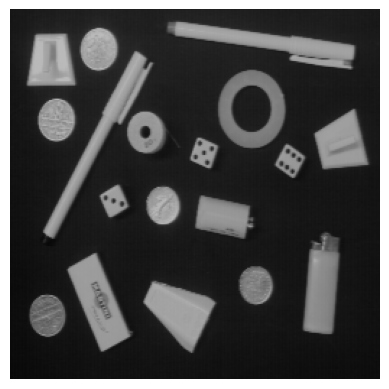

In [183]:
objects_img = cv2.imread('images/OBJECTS.png', cv2.IMREAD_GRAYSCALE)

plt.imshow(objects_img, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

#### 1.3 Visualice el histograma de la imagen de trabajo

In [184]:
def get_histogram(img):
    return cv2.calcHist([img],[0],None,[256],[0,256])

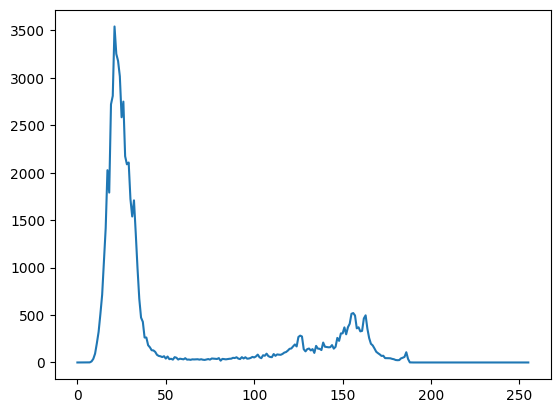

In [185]:
objects_hist = get_histogram(objects_img)

plt.plot(objects_hist)
plt.show()

#### 1.4 Aplique el algoritmo de umbralización global

In [186]:
max_value = 255
thresh_value, thresh_image = cv2.threshold(objects_img, 60, max_value, cv2.THRESH_BINARY)

#### 1.5 Aplique el algoritmo de umbralización de Otsu con un solo valor

In [187]:
otsu_value, otsu_image = cv2.threshold(objects_img, 0, max_value, cv2.THRESH_BINARY+cv2.THRESH_OTSU)

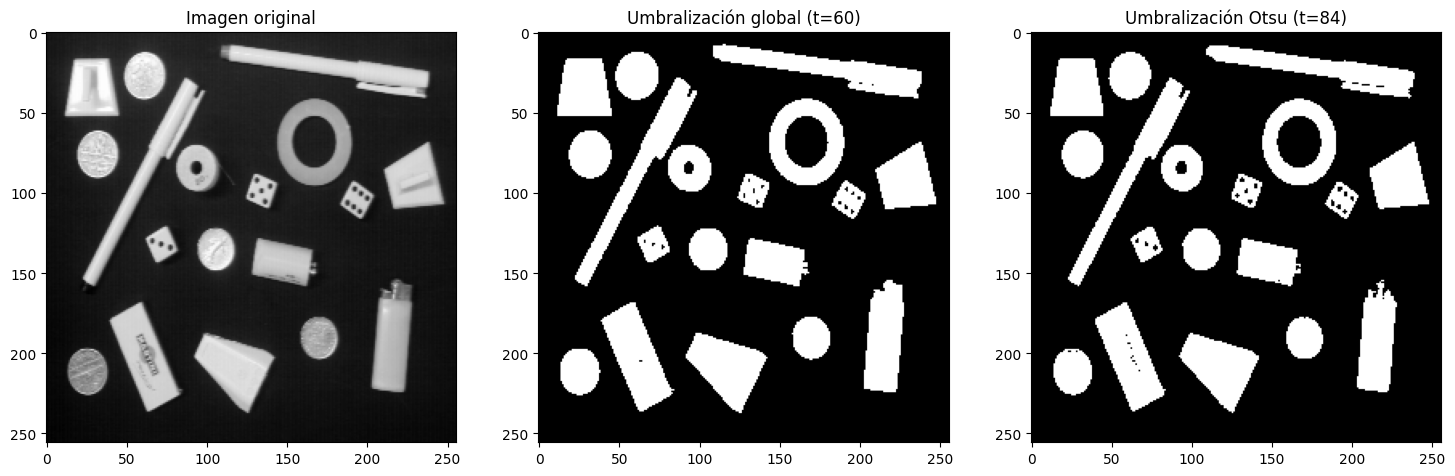

In [188]:
plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
plt.title('Imagen original')
plt.imshow(objects_img, cmap='gray')

plt.subplot(1,3,2)
plt.title(f'Umbralización global (t={int(thresh_value)})')
plt.imshow(thresh_image, cmap='gray')

plt.subplot(1,3,3)
plt.title(f'Umbralización Otsu (t={int(otsu_value)})')
plt.imshow(otsu_image, cmap='gray')

plt.show()

#### 1.6 Ahora introduzca ruido gaussiano aditivo con varianza de 0.001 y luego con varianza de 0.05. Visualice el histograma de la imagen resultante. ¿Qué sucede? ¿Por qué sucede esto?

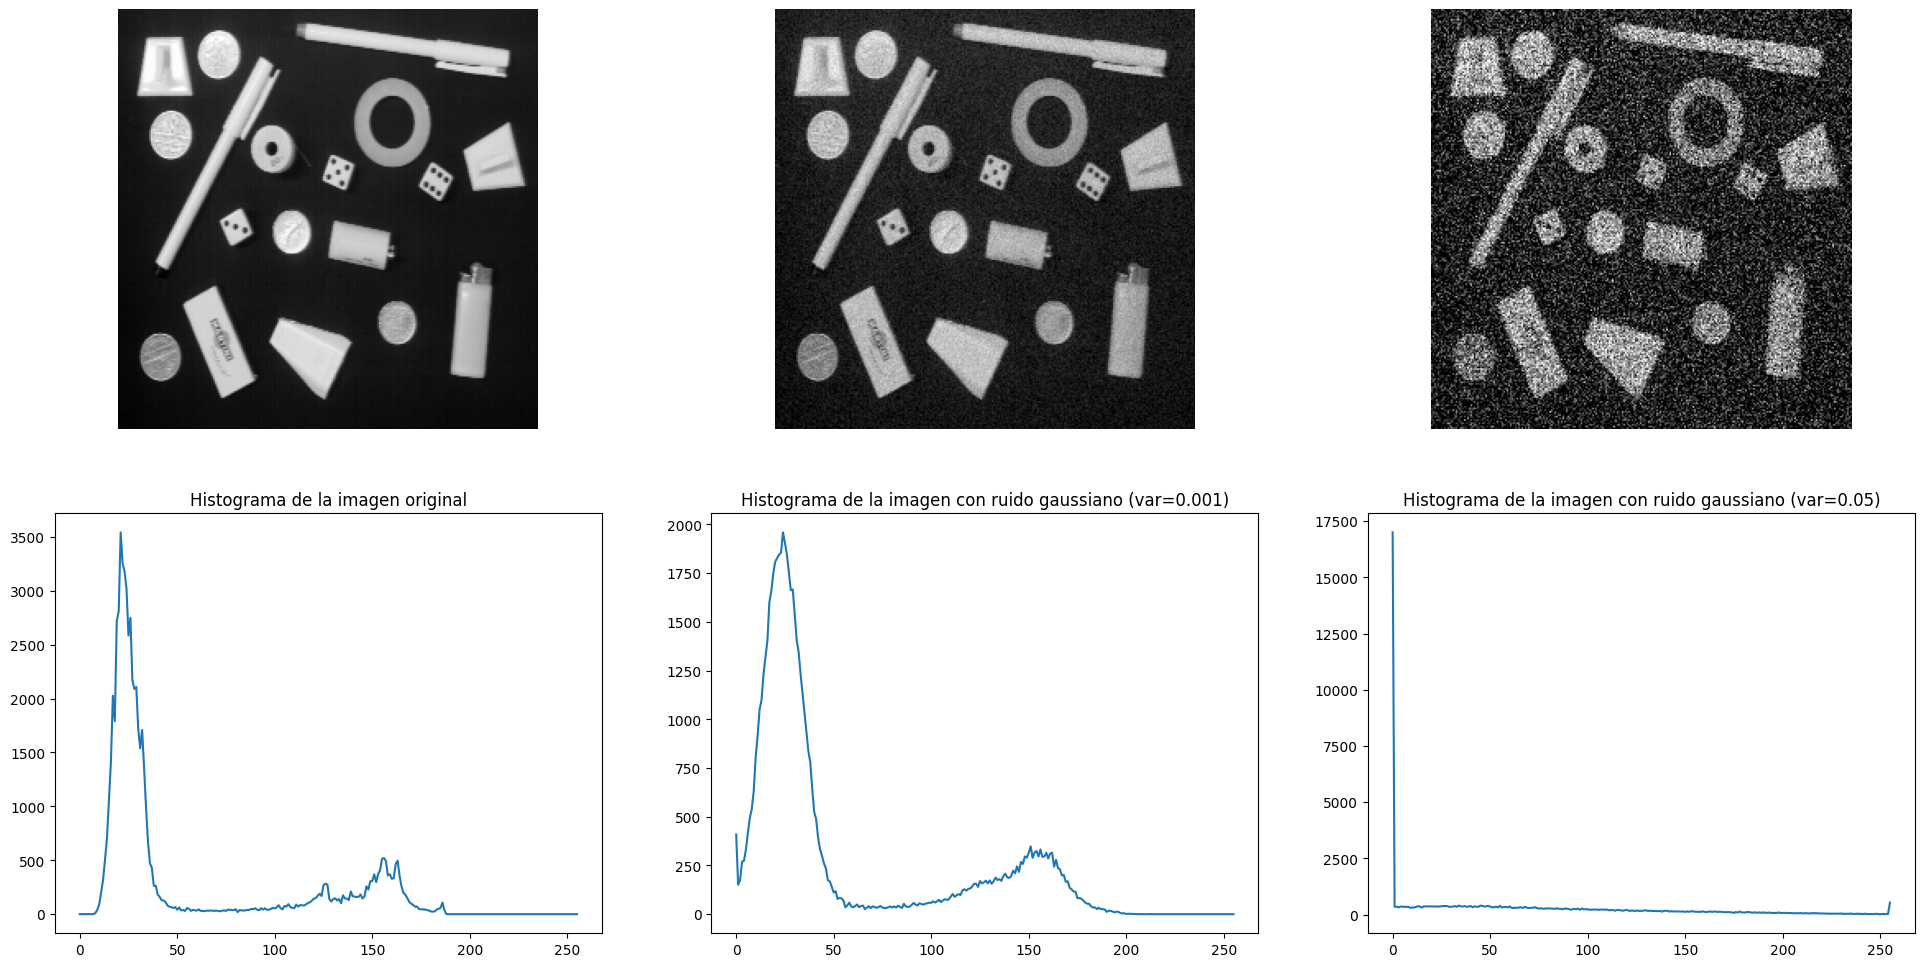

In [189]:

from skimage.util import random_noise

var1 = 0.001
var2 = 0.05

noised_image_001 = random_noise(objects_img, mode='gaussian', mean=0, var=var1)
noised_image_05 = random_noise(objects_img, mode='gaussian', mean=0,  var=var2)

noised_image_001 = (noised_image_001 * 255).astype(np.uint8)
noised_image_05 = (noised_image_05 * 255).astype(np.uint8)

noised_image_001_hist = get_histogram(noised_image_001)
noised_image_05_hist = get_histogram(noised_image_05)

plt.figure(figsize=(24, 12))

plt.subplot(2, 3, 1)
plt.imshow(objects_img, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(noised_image_001, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(noised_image_05, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.plot(objects_hist)
plt.title('Histograma de la imagen original')

plt.subplot(2, 3, 5)
plt.plot(noised_image_001_hist)
plt.title(f'Histograma de la imagen con ruido gaussiano (var={var1})')

plt.subplot(2, 3, 6)
plt.plot(noised_image_05_hist)
plt.title(f'Histograma de la imagen con ruido gaussiano (var={var2})')

plt.show()

Cuando la varianza del ruido es baja ($\sigma^2$ = 0.001), los picos del histograma que representan los valores de fondo (rango [10, 50]) y de los objetos (rango [100, 200]) incrementan su rango, pudiendose decir que se hacen más anchos: el pico que representa los valores de fondo se extiende poco, de [10,50] a [0, 50], pero se ve menos filudo porque los valores se distribuyen de manera más uniforme, ya el pico no es en 3500, sino en 1900. Adicionalmente, el valle que separa a ambos picos se vuelve menos profundo y más corto, implicando una mezcla entre los valores de intensidad de los objetos y el fondo. De todos modos, se observa que la estructura bimodal del histograma se mantiene.

Cuando la varianza del ruido es más alta ($\sigma^2$ = 0.001$), la estructura bimodal del histograma desaparece, mostrando qye no hay una distinción clara entre los objetos y el fondo. Además, hay un aplanamiento drástico del hitograma, donde solo presenta un pico en 0. Este pico también se explica dado que al sumar valores que pueden estar más alejados del valor original del píxel, los valores resultantes pueden ser negativos, por lo que recortan en 0 para cumplir con el rango de valores de la imagen.

Esto sucede porque al sumar ruido gaussiano, se le está sumando una variable aleatorio $N(0, \sigma^2)$ a las intensidades de los píxeles. Esto mueve los valores de los píxeles de manera aleatoria, y a mayor varianza, más ancha es la distribución de la variable aleatoria, por lo que el histograma original se aplana más. Esto se puede observar en la gráfica generada por el siguiente bloque de código (tener en cuenta que para esta suma los valores de intensidad de la imagen se convierten al rango [0, 1]).

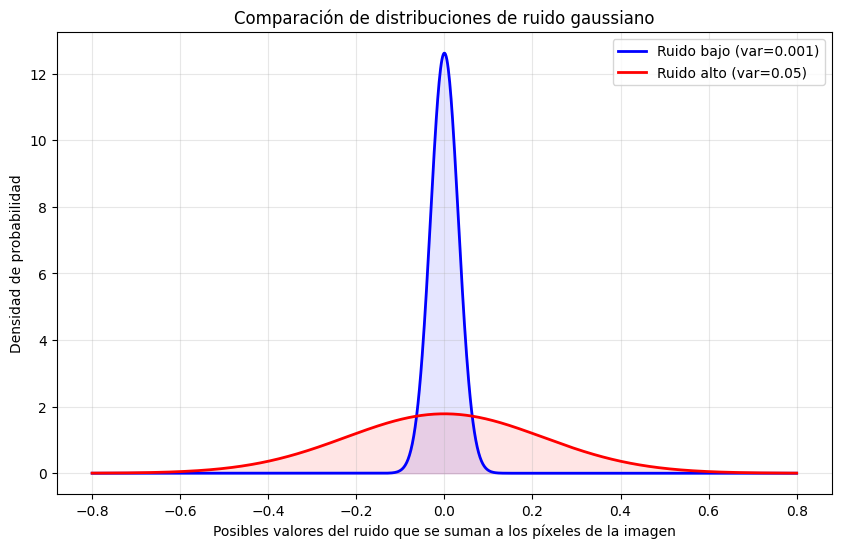

In [190]:
from scipy.stats import norm

x = np.linspace(-0.8, 0.8, 1000)

std1 = np.sqrt(var1)
std2 = np.sqrt(var2)

# genrar las distribuiones de probabilidad que representan el ruido
y1 = norm.pdf(x, 0, std1)
y2 = norm.pdf(x, 0, std2)

plt.figure(figsize=(10, 6))
plt.plot(x, y1, label=f'Ruido bajo (var={var1})', color='blue', linewidth=2)
plt.plot(x, y2, label=f'Ruido alto (var={var2})', color='red', linewidth=2)
plt.fill_between(x, y1, alpha=0.1, color='blue')
plt.fill_between(x, y2, alpha=0.1, color='red')

plt.title('Comparación de distribuciones de ruido gaussiano')
plt.xlabel('Posibles valores del ruido que se suman a los píxeles de la imagen')
plt.ylabel('Densidad de probabilidad')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### 1.7 Vuelva a correr las umbralizaciones sobre la imagen ¿Cómo afecta el ruido al resultado? 

Valores de umbrales
Original: 84.0
var=0.001: 84.0
var=0.05: 84.0


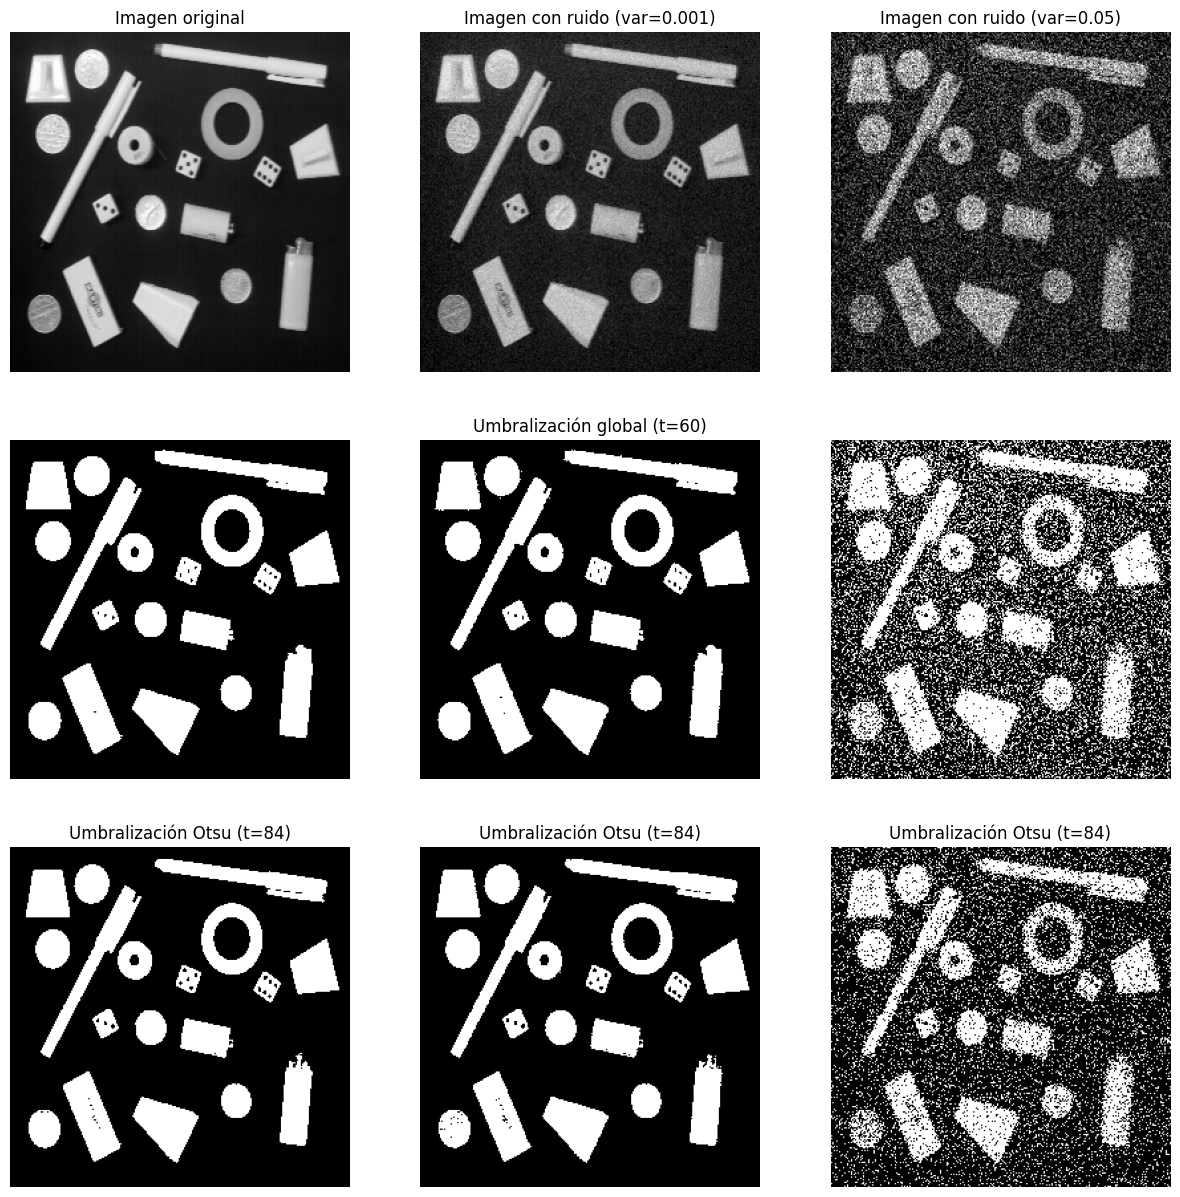

In [191]:
thresh_value, thresh_image_001 = cv2.threshold(noised_image_001, 60, max_value, cv2.THRESH_BINARY)
thresh_value, thresh_image_05 = cv2.threshold(noised_image_05, 60, max_value, cv2.THRESH_BINARY)

otsu_value_001, otsu_image_001 = cv2.threshold(noised_image_001, 0, max_value, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
otsu_value_05, otsu_image_05 = cv2.threshold(noised_image_05, 0, max_value, cv2.THRESH_BINARY+cv2.THRESH_OTSU)

print("Valores de umbrales")
print(f"Original: {otsu_value}")
print(f"var={var1}: {otsu_value_001}")
print(f"var={var2}: {otsu_value_05}")

plt.figure(figsize=(15,15))

plt.subplot(3,3,1)
plt.imshow(objects_img, cmap='gray')
plt.title('Imagen original')
plt.axis('off')

plt.subplot(3,3,2)
plt.imshow(noised_image_001, cmap='gray')
plt.title(f'Imagen con ruido (var={var1})')
plt.axis('off')

plt.subplot(3,3,3)
plt.imshow(noised_image_05, cmap='gray')
plt.title(f'Imagen con ruido (var={var2})')
plt.axis('off')

plt.subplot(3,3,4)
plt.imshow(thresh_image, cmap='gray')
plt.axis('off')

plt.subplot(3,3,5)
plt.imshow(thresh_image_001, cmap='gray')
plt.title(f'Umbralización global (t={round(thresh_value)})')
plt.axis('off')

plt.subplot(3,3,6)
plt.imshow(thresh_image_05, cmap='gray')
plt.axis('off')

plt.subplot(3,3,7)
plt.imshow(otsu_image, cmap='gray')
plt.title(f'Umbralización Otsu (t={int(otsu_value)})')
plt.axis('off')

plt.subplot(3,3,8)
plt.imshow(otsu_image_001, cmap='gray')
plt.title(f'Umbralización Otsu (t={round(otsu_value_001)})')
plt.axis('off')

plt.subplot(3,3,9)
plt.imshow(otsu_image_05, cmap='gray')
plt.title(f'Umbralización Otsu (t={round(otsu_value_05)})')
plt.axis('off')

plt.show()


El ruido gaussiano bajo, con $\sigma^2 = 0.001$, no causa un cambio mayor en el resultado de la umbralización. Al aplicar el ruido bajo, el desplazamiento de los valores de intensidad de la imagen no causa un cambio mayor en los rangos de intensidad de fondo y objetos, por lo que al usar el mismo umbral, se obtiene un resultado similar a cuando se umbraliza la imagen original, y lo mismo se observa al hacer la umbralización Otsu. 

En cambio, cuando el ruido gaussiano tiene alta varianza, con $\sigma^2 = 0.05$, el desplazamiento de los valores de intensidad de la imagen causa un cambio mayor en los rangos de intensidad de fondo y objetos, por lo que al usar el mismo umbral, se obtiene un resultado diferente a cuando se umbraliza la imagen original, y lo mismo se observa al hacer la umbralización Otsu. En este caso, ambas umbralizaciones toman zonas del fondo como objetos y partes de los objetos como fondo. 

Algo curioso que se observa es que la umbralización de Otsu calcula el mismo umbral para las tres imágenes. Esto es una coincidencia matemática, aunque el histograma cambie drásticamente (pico en 0, y una distribución totalmente plana), las proporciones globales enter píxeles oscuros y claros se preservan de forma que 84 sigue siendo el umbral óptimo. Sin embargo, la segmentación es de mucho peor calidad por el ruido que causa que los píxeles de fondo crucen al otro lado del umbral, y lo mismo pase en dirección contraria.

#### 1.8 Cargue ahora la imagen de trabajo text, visualícela y visualice su histograma.

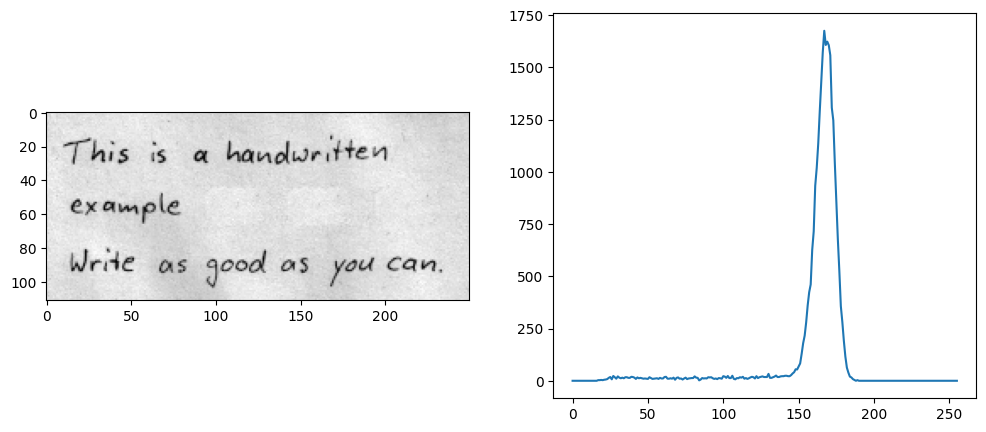

In [192]:
text_img = cv2.imread('images/Text.png', cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(text_img, cmap='gray')
plt.subplot(1,2,2)
text_hist = get_histogram(text_img)
plt.plot(text_hist)
plt.show()

#### 1.9 Introduzca ahora una sombra circular lateral y una sombra sinusoidal en la imagen (pruebe con diferentes valores y úselos para los pasos 10 y 11). Visualice el resultado.


In [193]:

def add_circular_shade(img):
    rows, cols = img.shape
    x, y = np.meshgrid(np.arange(cols), np.arange(rows))
    #Cálculo del centro
    cx, cy = cols // 2, rows // 2  
    #Cálculo del radio y distancia posible
    distance = np.sqrt((x - cx) ** 2 + (y - cy) ** 2)
    max_dist = np.sqrt(cx**2 + cy**2) 

    #Aplicación del gradiente
    spot_shading = 1 - (distance / max_dist)  
    spot_image = img * spot_shading

    spot_image = spot_image.astype(np.uint8)
    return spot_image

def add_sinusoidal_shade(img, period=50, amplitude=0.5):
    # Cantidad de perturbaciones
    period = period
    #Intensidad de los picos
    amplitude = amplitude 
    
    rows, cols = img.shape

    x, y = np.meshgrid(np.arange(cols), np.arange(rows))

    #Cálculo y aplicación del efecto
    sinusoidal_shading = (1 + amplitude * np.sin(2 * np.pi * x / period)) / 1.5
    sinusoidal_image = img * sinusoidal_shading

    sinusoidal_image = sinusoidal_image.astype(np.uint8)
    
    return sinusoidal_image

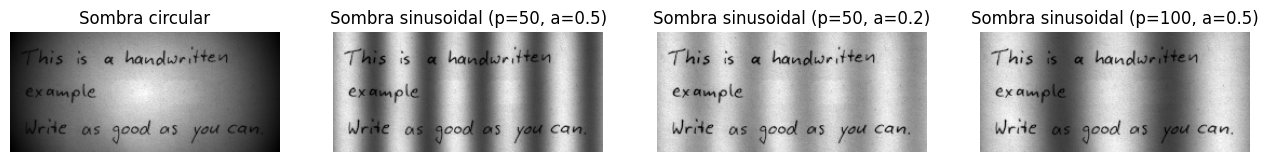

In [194]:
text_with_circular_shade = add_circular_shade(text_img)
text_with_sinusoidal_shade1 = add_sinusoidal_shade(text_img)
text_with_sinusoidal_shade2 = add_sinusoidal_shade(text_img, amplitude=0.2)
text_with_sinusoidal_shade3 = add_sinusoidal_shade(text_img, period=100)

plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.imshow(text_with_circular_shade, cmap='gray')
plt.title('Sombra circular')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(text_with_sinusoidal_shade1, cmap='gray')
plt.title('Sombra sinusoidal (p=50, a=0.5)')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(text_with_sinusoidal_shade2, cmap='gray')
plt.title('Sombra sinusoidal (p=50, a=0.2)')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(text_with_sinusoidal_shade3, cmap='gray')
plt.title('Sombra sinusoidal (p=100, a=0.5)')
plt.axis('off')

plt.show()

#### 1.10 Aplique el algoritmo de umbralización de Otsu sobre la imagen original y las dos modificaciones. ¿Qué sucede? ¿Por qué sucede esto? ¿Qué alternativas puede emplear para mitigar este resultado?

In [195]:
otsu_og, otsu_text_image = cv2.threshold(text_img, 0, max_value, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
otsu_cs, otsu_cs_image = cv2.threshold(text_with_circular_shade, 0, max_value, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
otsu_ss1, otsu_ss1_image = cv2.threshold(text_with_sinusoidal_shade1, 0, max_value, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
otsu_ss2, otsu_ss2_image = cv2.threshold(text_with_sinusoidal_shade2, 0, max_value, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
otsu_ss3, otsu_ss3_image = cv2.threshold(text_with_sinusoidal_shade3, 0, max_value, cv2.THRESH_BINARY+cv2.THRESH_OTSU)

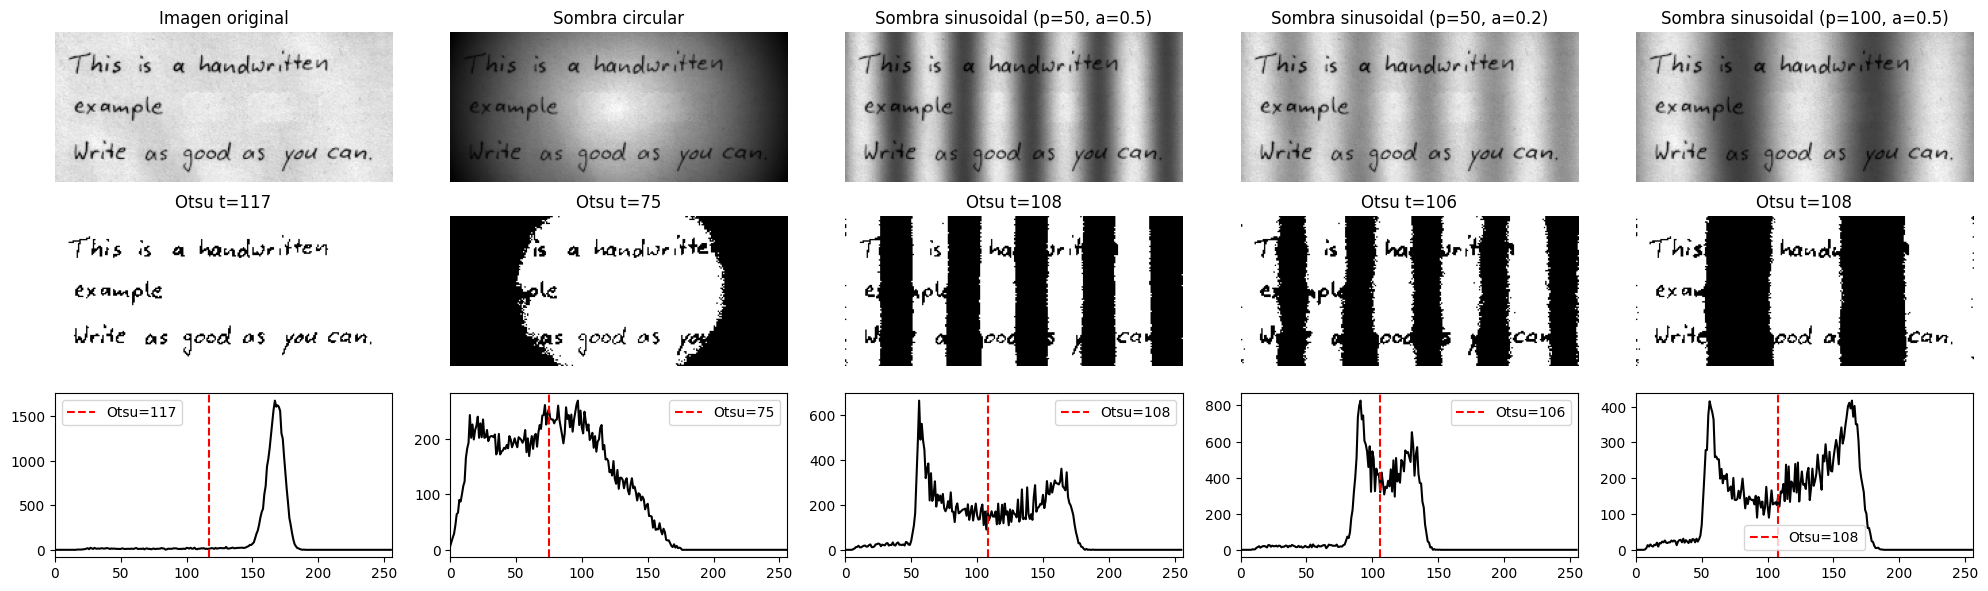

In [196]:
plt.figure(figsize=(20, 6))

plt.subplot(3, 5, 1)
plt.imshow(text_img, cmap='gray')
plt.title('Imagen original')
plt.axis('off')

plt.subplot(3, 5, 2)
plt.imshow(text_with_circular_shade, cmap='gray')
plt.title('Sombra circular')
plt.axis('off')

plt.subplot(3, 5, 3)
plt.imshow(text_with_sinusoidal_shade1, cmap='gray')
plt.title('Sombra sinusoidal (p=50, a=0.5)')
plt.axis('off')

plt.subplot(3, 5, 4)
plt.imshow(text_with_sinusoidal_shade2, cmap='gray')
plt.title('Sombra sinusoidal (p=50, a=0.2)')
plt.axis('off')

plt.subplot(3, 5, 5)
plt.imshow(text_with_sinusoidal_shade3, cmap='gray')
plt.title('Sombra sinusoidal (p=100, a=0.5)')
plt.axis('off')

plt.subplot(3, 5, 6)
plt.imshow(otsu_text_image, cmap='gray')
plt.title(f'Otsu t={int(otsu_og)}')
plt.axis('off')

plt.subplot(3, 5, 7)
plt.imshow(otsu_cs_image, cmap='gray')
plt.title(f'Otsu t={int(otsu_cs)}')
plt.axis('off')

plt.subplot(3, 5, 8)
plt.imshow(otsu_ss1_image, cmap='gray')
plt.title(f'Otsu t={int(otsu_ss1)}')
plt.axis('off')

plt.subplot(3, 5, 9)
plt.imshow(otsu_ss2_image, cmap='gray')
plt.title(f'Otsu t={int(otsu_ss2)}')
plt.axis('off')

plt.subplot(3, 5, 10)
plt.imshow(otsu_ss3_image, cmap='gray')
plt.title(f'Otsu t={int(otsu_ss3)}')
plt.axis('off')

plt.subplot(3, 5, 11)
hist_og = get_histogram(text_img)
plt.plot(hist_og, color='black')
plt.axvline(x=otsu_og, color='red', linestyle='--', label=f'Otsu={int(otsu_og)}')
plt.legend()
plt.xlim([0, 256])

plt.subplot(3, 5, 12)
hist_cs = get_histogram(text_with_circular_shade)
plt.plot(hist_cs, color='black')
plt.axvline(x=otsu_cs, color='red', linestyle='--', label=f'Otsu={int(otsu_cs)}')
plt.legend()
plt.xlim([0, 256])

plt.subplot(3, 5, 13)
hist_ss1 = get_histogram(text_with_sinusoidal_shade1)
plt.plot(hist_ss1, color='black')
plt.axvline(x=otsu_ss1, color='red', linestyle='--', label=f'Otsu={int(otsu_ss1)}')
plt.legend()
plt.xlim([0, 256])

plt.subplot(3, 5, 14)
hist_ss2 = get_histogram(text_with_sinusoidal_shade2)
plt.plot(hist_ss2, color='black')
plt.axvline(x=otsu_ss2, color='red', linestyle='--', label=f'Otsu={int(otsu_ss2)}')
plt.legend()
plt.xlim([0, 256])

plt.subplot(3, 5, 15)
hist_ss3 = get_histogram(text_with_sinusoidal_shade3)
plt.plot(hist_ss3, color='black')
plt.axvline(x=otsu_ss3, color='red', linestyle='--', label=f'Otsu={int(otsu_ss3)}')
plt.legend()
plt.xlim([0, 256])

plt.tight_layout()
plt.show()

**Observación:** El código de ejemplo dado para el taller parece tener un error, ya que usan una variable llamada `frequency` para generar las sombras sinusoidales. Pero, al pasar un mayor valor a la variable `frequency`, el resultado es que las sombras se vuelven más gruesas y aparecen menos secciones sombreadas en el papel. Al incrementar la frecuencia lo que debería suceder es que las sombras se vuelvan más delgadas en lugar de más gruesas, y deberían de aparecer más secciones sombreadas en el papel. Lo que sucede es lo opuesto, por lo que la variable `frequency` debería ser llamada `period`.

En la imagen original la iluminación es uniforme, pero esto, Otsu logra separar correctamente los objetos del fondo, donde se observan las letras de manera clara.

En cambio, en las imágene con sombras, en las zonas con buena iluminación el texto se segmenta correctamente, pero en las zonas de sombra el algoritmo clasifica el papel como parte del texto, debido a que en estas zonas el contraste entre letras y papel es menor, y los niveles de intensidad son similares y bajos. Así, la mancha de la sombra aparece segmentada como un objeto sólido en esas zonas.

Esto sucede porque otsu de un umbral global asume que el histograma de la imagen es bimodal (dos picos) o unimodal (un pico), donde un pico representa los objetos de interés y el otro los objetos de fondo y se busca un único valor de umbral para toda la imagen. Al introducir sombras a la imagen se cambia la intensidad del fondo en varias zonas. Los píxeles del fondo en las zonas de sombra se vuelven tan oscuros que sus valores de intensidad caen en el mismo rango que los píxeles de las letras. Como se puede observar en los histogramas, estas distribuciones se mezclan y los valles suben sus valores, y en casos como el de la sombra circular, el valle y el pico desaparecen, por lo que el algoritmo no puede encontrar un umbral global que se ajuste a la imagen.

Una alternativa para mitigar este resultado es usar umbralización adaptativa, que busca umbrales locales para cada región de la imagen, así la umbralización se ajusta a la iluminación local de cada región. Para esto, la imagen se divide en varias regiones disyuntas, en forma de cuadrícula, y se aplica el algoritmo de umbralización de Otsu a cada región por separado.

En este caso específico, parece que se requieren cuadrículas de solo una fila para las imágenes que tienen sombras sinusoidales, pues las sombras son verticales, y el número de columnas dependería de la frecuencia de las sombras. En el caso de la sombra circular, se requieren cuadrículas con más de una fila y columna, pues como es circular, el comportamiento de la luminosidad haciendo un barrido vertical muestra cambios.

#### 1.11 Aplique ahora un algoritmo de adaptacion del umbral en función de las propiedades locales. Compare sus resultados con el algoritmo anterior, usando varios valores para el vecindario local. ¿En qué cambia el resultado con relación al método de Otsu? ¿Qué implicaciones tiene esto? ¿Cómo puede mejorar el resultado de la segmentación para reducir el ruido en ambos casos?

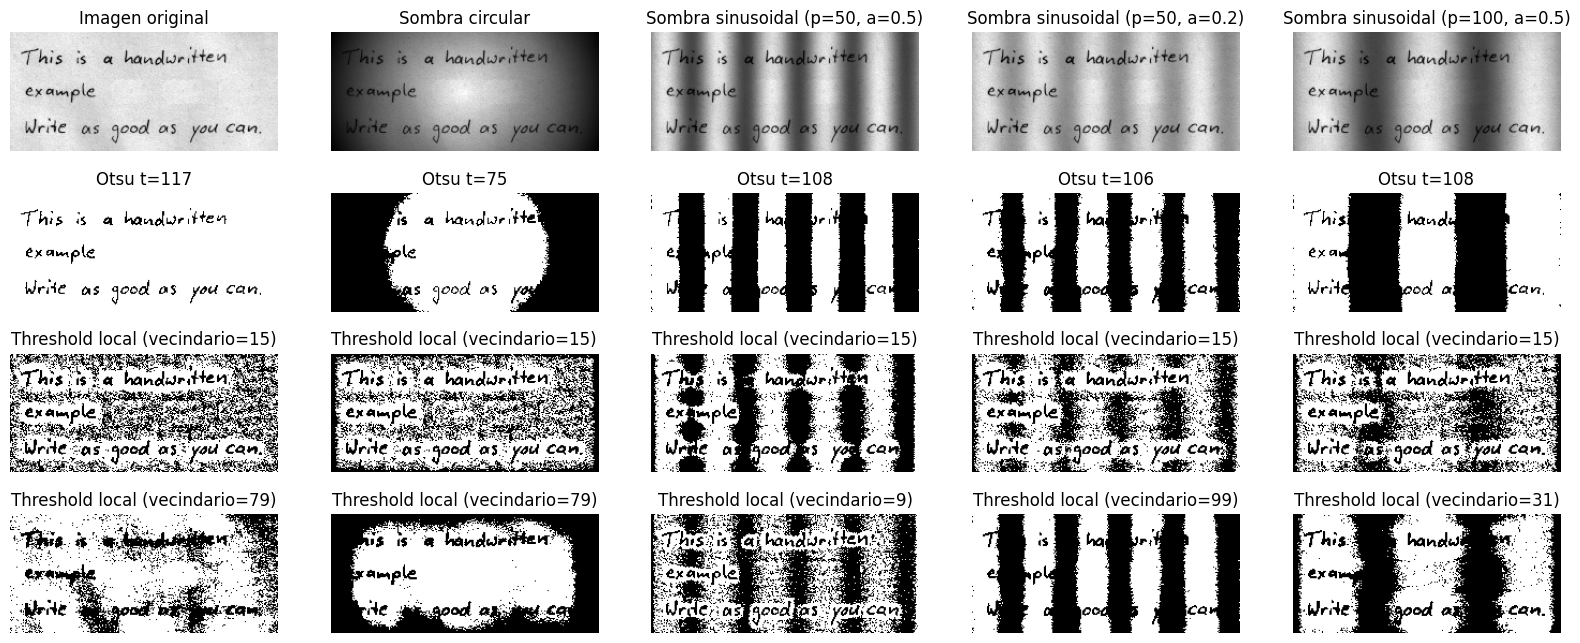

In [197]:
from skimage.filters import threshold_local

imgs = [text_img, text_with_circular_shade, text_with_sinusoidal_shade1, text_with_sinusoidal_shade2, text_with_sinusoidal_shade3]

plt.figure(figsize=(20, 8))
plt.subplot(4, 5, 1)
plt.imshow(text_img, cmap='gray')
plt.title('Imagen original')
plt.axis('off')

plt.subplot(4, 5, 2)
plt.imshow(text_with_circular_shade, cmap='gray')
plt.title('Sombra circular')
plt.axis('off')

plt.subplot(4, 5, 3)
plt.imshow(text_with_sinusoidal_shade1, cmap='gray')
plt.title('Sombra sinusoidal (p=50, a=0.5)')
plt.axis('off')

plt.subplot(4, 5, 4)
plt.imshow(text_with_sinusoidal_shade2, cmap='gray')
plt.title('Sombra sinusoidal (p=50, a=0.2)')
plt.axis('off')

plt.subplot(4, 5, 5)
plt.imshow(text_with_sinusoidal_shade3, cmap='gray')
plt.title('Sombra sinusoidal (p=100, a=0.5)')
plt.axis('off')

plt.subplot(4, 5, 6)
plt.imshow(otsu_text_image, cmap='gray')
plt.title(f'Otsu t={int(otsu_og)}')
plt.axis('off')

plt.subplot(4, 5, 7)
plt.imshow(otsu_cs_image, cmap='gray')
plt.title(f'Otsu t={int(otsu_cs)}')
plt.axis('off')

plt.subplot(4, 5, 8)
plt.imshow(otsu_ss1_image, cmap='gray')
plt.title(f'Otsu t={int(otsu_ss1)}')
plt.axis('off')

plt.subplot(4, 5, 9)
plt.imshow(otsu_ss2_image, cmap='gray')
plt.title(f'Otsu t={int(otsu_ss2)}')
plt.axis('off')

plt.subplot(4, 5, 10)
plt.imshow(otsu_ss3_image, cmap='gray')
plt.title(f'Otsu t={int(otsu_ss3)}')
plt.axis('off')

# Aplicar threshold local
X = 15
for i, img in enumerate(imgs):
    ti = threshold_local(img, block_size=X, method='mean')
    binary_image = img > ti
    thresholded_image = binary_image * 255
    
    plt.subplot(4, 5, 11 + i)
    plt.imshow(thresholded_image, cmap='gray')
    plt.title(f'Threshold local (vecindario={X})')
    plt.axis('off')
    
X_list = [79, 79, 9, 99, 31]
for i, x in enumerate(X_list):
    img = imgs[i]
    ti = threshold_local(img, block_size=x, method='mean')
    binary_image = img > ti
    thresholded_image = binary_image * 255
    
    plt.subplot(4, 5, 16 + i)
    plt.imshow(thresholded_image, cmap='gray')
    plt.title(f'Threshold local (vecindario={x})')
    plt.axis('off')
    
plt.show()

Mientras que el método de Otsu asume una iluminación uniforme y calcula un único umbral global para toda la imagen, la umbralización adaptativa determina un umbral específico para cada píxel basándose en la intensidad promedio de sus vecinos. Esto explica por qué Otsu falla en las zonas de sombra, clasificando erróneamente el fondo oscuro como texto, mientras que el método adaptativo logra seguir la curva de intensidad de la sombra y recuperar la información oculta. Pero, el algoritmo de umbralización local utilizado, a cambio de ganar robustez frente a sombras, pierde robustez frente al ruido en zonas homogéneas. El algoritmo asume que siempre hay algo que separar en cada vecindario y esto genera mucho ruido en el fondo cuando el vecindario es pequeño (ej: 15). En áreas planas (sin texto), la varianza local es baja y cualquier pequeña fluctuación de ruido en la imagen hace que el píxel evaluado supere o caiga debajo del umbral del promedio local, creando el efecto de sal y pimienta observado en el fondo. Cuando se selecciona un vecindario grande, el fondo tiende a tener menos ruido como se observa en los resultados con un umbral de 79, pero el algoritmo empieza a comportarse como una umbralización global, observado con el venciadrio de 99, cuyo resultado resulta muy similar al obtenido con Otsu.

Para mitigar estos efectos no deseados y mejorar la calidad de la segmentación, es necesario aplicar estrategias de pre y post-procesamiento. Antes de umbralizar, se puede aplicar un filtro de gaussiano para suavizar las variaciones de alta frecuencia y reducir el ruido natural introducido por la captación. En post procesamiento se puede invertir la imagen para que el texto tenga valores altos de intensidad (blancos), y se pueden aplicar operaciones morfológicas como una apertura (erosión seguida de dilatación) para eliminar los puntos de ruido en el fondo sin afectar el texto.

Para la umbralización global de Otsu, se pueden hacer umbralizaciones de Otsu locales como se propueso en la sección 1.10, en lugar de utilizar la media. 

## 2. 